# TF-IDF Analysis by Tipe Dokumen (Document Type)

Classifies articles by document type (straight news, opinion, analysis, etc.) then computes TF-IDF per type.

**Pipeline:**
1. Classify each article's type using URL path patterns and keyword heuristics
2. Group articles by type
3. Compute TF-IDF per type to reveal vocabulary differences

In [1]:
!pip install nltk Sastrawi pandas scikit-learn matplotlib seaborn -q


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import re
from urllib.parse import urlparse

from sklearn.feature_extraction.text import TfidfVectorizer

import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded.")

Libraries loaded.


## 1. Load Dataset

In [3]:
path = "../../preprocessed/dataset_preprocessed_bert.csv"
df = pd.read_csv(path)
df = df.dropna(subset=['konten_preprocessed'])

print(f"Dataset: {len(df)} articles")
print(f"Columns: {list(df.columns)}")
df.head(3)

Dataset: 999 articles
Columns: ['url', 'judul', 'konten', 'manual sentiment', 'konten_length', 'konten_preprocessed']


,url,judul,konten,manual sentiment,konten_length,konten_preprocessed
0,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",Positive,8328,jakarta cnbc indonesia amerika serikat as seca...
1,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",Positive,2925,jakarta cnbc indonesia nilai tukar rupiah terh...
2,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",Positive,13102,jakarta cnbc indonesia pasar keuangan indonesi...


## 2. Classify Document Type

Document type is inferred using a combination of:
1. **URL path patterns** (e.g., `/opini/`, `/kolom/`, `/analisis/` in the URL)
2. **Title keywords** (e.g., titles starting with "Opini:", "Analisis:", "Kolom:")
3. **Content structure heuristics** (length, presence of first-person pronouns)

Categories:
- **Berita** (Straight News): factual reporting
- **Opini** (Opinion): subjective perspective pieces, columns
- **Analisis** (Analysis): in-depth analytical articles
- **Feature**: long-form, narrative journalism
- **Wawancara** (Interview): interview-based articles

In [4]:
def classify_document_type(url, title, content, content_length):
    """
    Classify article document type using URL, title, and content heuristics.
    Returns one of: 'Opini', 'Analisis', 'Wawancara', 'Feature', 'Berita'
    """
    url_lower = str(url).lower() if isinstance(url, str) else ''
    title_lower = str(title).lower() if isinstance(title, str) else ''
    content_lower = str(content).lower() if isinstance(content, str) else ''
    
    # === Rule 1: URL path patterns ===
    opini_url_patterns = [
        '/opini/', '/kolom/', '/column/', '/perspektif/', '/editorial/',
        '/suara-pembaca/', '/tajuk/', '/redaksi/', '/opini-',
        '/surat-pembaca/', '/gagasan/', '/wacana/',
    ]
    analisis_url_patterns = [
        '/analisis/', '/analysis/', '/riset/', '/research/',
        '/infografis/', '/data/', '/indepth/', '/in-depth/',
    ]
    wawancara_url_patterns = [
        '/wawancara/', '/interview/', '/profil/', '/profile/',
    ]
    feature_url_patterns = [
        '/feature/', '/fitur/', '/long-read/', '/longread/',
        '/narasi/', '/cerita/', '/liputan-khusus/',
    ]
    
    for pattern in opini_url_patterns:
        if pattern in url_lower:
            return 'Opini'
    for pattern in analisis_url_patterns:
        if pattern in url_lower:
            return 'Analisis'
    for pattern in wawancara_url_patterns:
        if pattern in url_lower:
            return 'Wawancara'
    for pattern in feature_url_patterns:
        if pattern in url_lower:
            return 'Feature'
    
    # === Rule 2: Title keywords ===
    opini_title_kw = ['opini:', 'kolom:', 'editorial:', 'tajuk:', 'perspektif:',
                      'opini |', '| opini', 'kolom |', '| kolom',
                      'surat pembaca', 'catatan redaksi']
    analisis_title_kw = ['analisis:', 'analysis:', 'riset:', 'data:',
                         'infografis:', 'analisis |', '| analisis']
    wawancara_title_kw = ['wawancara:', 'interview:', 'wawancara eksklusif',
                          'wawancara khusus']
    
    for kw in opini_title_kw:
        if kw in title_lower:
            return 'Opini'
    for kw in analisis_title_kw:
        if kw in title_lower:
            return 'Analisis'
    for kw in wawancara_title_kw:
        if kw in title_lower:
            return 'Wawancara'
    
    # === Rule 3: Content heuristics ===
    # Heavy use of first-person pronouns suggests opinion
    first_person = len(re.findall(r'\b(saya|menurut saya|penulis|kami berpendapat|hemat saya)\b', content_lower))
    if first_person >= 3:
        return 'Opini'
    
    # Interview markers
    interview_markers = len(re.findall(r'\b(pewawancara|narasumber|tanya|jawab|q:|a:)\b', content_lower))
    if interview_markers >= 5:
        return 'Wawancara'
    
    # Long articles with analytical depth
    if isinstance(content_length, (int, float)) and content_length > 5000:
        analytical_kw = len(re.findall(
            r'\b(berdasarkan data|menurut analisis|proyeksi|tren|grafik|statistik|survei|studi)\b',
            content_lower))
        if analytical_kw >= 3:
            return 'Analisis'
    
    # Default: straight news
    return 'Berita'


# Apply classification
df['doc_type'] = df.apply(
    lambda row: classify_document_type(
        row['url'], row['judul'], row['konten'], row.get('konten_length', 0)
    ), axis=1
)

print("Document type distribution:")
type_counts = df['doc_type'].value_counts()
print(type_counts)
print(f"\nTotal types: {df['doc_type'].nunique()}")

Document type distribution:
doc_type
Berita      854
Opini        76
Analisis     69
Name: count, dtype: int64

Total types: 3


In [5]:
# Show some examples per type
for dtype in df['doc_type'].unique():
    print(f"\n--- {dtype} (sample titles) ---")
    samples = df[df['doc_type'] == dtype]['judul'].head(3).tolist()
    for s in samples:
        print(f"  {str(s)[:80]}")


--- Analisis (sample titles) ---
  Trump Sebar Exceutive Order: Emang Semengerikan Apa Buat Indonesia? - CNBC Indon
  Alasan Rupiah 'Berpesta' di Pelantikan Trump, Dolar Bisa Rp15.000an? - CNBC Indo
  Trump Beri Kabar Baik, Saatnya Menunggu Dolar Eksportir Balik ke RI - CNBC Indon

--- Berita (sample titles) ---
  Bernstein: Bitcoin Bisa Naik 2x Lipat! Target $200K? - INDODAX
  IHSG Tertekan, BPJS Ketenagakerjaan dan Taspen Tambah Portofolio di Pasar Saham 
  Dampak Penangguhan Tarif Trump: Bitcoin Naik Pesat - INDODAX

--- Opini (sample titles) ---
  Penjelasan Lengkap Prabowo Respons Kebijakan Terbaru Tarif Trump AS - CNBC Indon
  Donald Trump dan Madman Theory - ANTARA News
  Kebijakan Tarif Trump: Antara Pro Competition Vs Pro Competitor - CNBC Indonesia


In [6]:
# ADJUST: Minimum articles per type to include
MIN_ARTICLES = 3

valid_types = type_counts[type_counts >= MIN_ARTICLES].index.tolist()
df_filtered = df[df['doc_type'].isin(valid_types)].copy()

print(f"Types with >= {MIN_ARTICLES} articles: {valid_types}")
print(f"Articles included: {len(df_filtered)} / {len(df)}")

Types with >= 3 articles: ['Berita', 'Opini', 'Analisis']
Articles included: 999 / 999


## 3. Preprocessing

In [7]:
stopword_factory = StopWordRemoverFactory()
indonesian_stopwords = set(stopword_factory.get_stop_words())

custom_stopwords = {
    'yang', 'dan', 'di', 'dari', 'untuk', 'pada', 'dengan',
    'ini', 'itu', 'ke', 'dalam', 'adalah', 'juga', 'tidak',
    'akan', 'ada', 'atau', 'bisa', 'sudah', 'lebih', 'oleh',
    'hal', 'saat', 'dapat', 'telah', 'mereka', 'saya', 'kami',
    'kita', 'hanya', 'seperti', 'tentang', 'antara', 'lain',
    'maka', 'jika', 'bagi', 'pun', 'lagi', 'masih', 'ia',
    'dia', 'anda', 'kata', 'ujar', 'ucap', 'tutur', 'sebut'
}
all_stopwords = indonesian_stopwords.union(custom_stopwords)

PUBLISHER_NOISE = sorted([
    'bloomberg news bloomberg', 'bloomberg news', 'bloomberg com',
    'reuters thomson reuters', 'thomson reuters', 'reuters com',
    'associated press', 'the associated press',
    'bloomberg technoz jakarta', 'cnbc indonesia', 'cnn indonesia',
    'kompas com', 'kompas tv', 'tribunnews com', 'detik com',
    'detikfinance', 'detikcom', 'liputan6 com', 'tempo co',
    'kontan co id', 'bisnis com', 'bisnis indonesia',
    'katadata co id', 'katadata', 'antara news', 'antaranews com',
    'okezone com', 'sindonews com', 'tirto id', 'kumparan com',
    'baca juga', 'baca selengkapnya', 'simak juga',
    'hak cipta', 'all rights reserved', 'copyright',
    'unduh aplikasi', 'download aplikasi',
    'sindonews berita terbaru', 'channel sindonews berita',
    'whatsapp channel sindonews', 'berita terbaru hari',
    'konten melakukan crawling', 'continue with content',
    'gambas video cnn', 'von der leyen', 'ursula von der',
    'federal reserve the', 'reserve the fed',
], key=len, reverse=True)


def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    for phrase in PUBLISHER_NOISE:
        text = text.replace(phrase, ' ')
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in all_stopwords and len(t) >= 3]
    return ' '.join(tokens)


print("Preprocessing...")
df_filtered['cleaned_text'] = df_filtered['konten_preprocessed'].apply(preprocess_text)
df_filtered = df_filtered[df_filtered['cleaned_text'].str.strip() != '']
print(f"Done! {len(df_filtered)} articles.")

Preprocessing...
Done! 999 articles.


## 4. TF-IDF per Tipe Dokumen

In [8]:
def tfidf_analysis(corpus, top_n=20):
    corpus_clean = [doc for doc in corpus if doc.strip()]
    if len(corpus_clean) < 2:
        return pd.DataFrame(columns=['Term', 'TF-IDF Score'])
    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=10000,
        sublinear_tf=True,
    )
    tfidf_matrix = vectorizer.fit_transform(corpus_clean)
    features = vectorizer.get_feature_names_out()
    mean_scores = tfidf_matrix.mean(axis=0).A1
    result = pd.DataFrame({'Term': features, 'TF-IDF Score': mean_scores})
    return result.sort_values('TF-IDF Score', ascending=False).head(top_n).reset_index(drop=True)

print("TF-IDF function ready.")

TF-IDF function ready.


In [9]:
TOP_N = 20

tfidf_per_type = {}

for dtype in sorted(valid_types):
    subset = df_filtered[df_filtered['doc_type'] == dtype]
    corpus = subset['cleaned_text'].tolist()
    
    df_result = tfidf_analysis(corpus, TOP_N)
    df_result['Document Type'] = dtype
    df_result['Article Count'] = len(subset)
    tfidf_per_type[dtype] = df_result
    
    print(f"--- {dtype} ({len(subset)} articles) ---")
    print(df_result[['Term', 'TF-IDF Score']].head(10).to_string(index=False))
    print()

--- Analisis (69 articles) ---
       Term  TF-IDF Score
      tarif      0.041833
      trump      0.033232
  indonesia      0.033030
     negara      0.029873
perdagangan      0.028915
      pasar      0.026179
  kebijakan      0.025753
      impor      0.025256
    menjadi      0.024763
    ekonomi      0.024416

--- Berita (854 articles) ---
       Term  TF-IDF Score
      tarif      0.038965
      trump      0.032798
     negara      0.029770
  indonesia      0.028516
      china      0.024582
  kebijakan      0.024533
perdagangan      0.024490
      impor      0.023600
    amerika      0.023454
   tersebut      0.022440

--- Opini (76 articles) ---
       Term  TF-IDF Score
      tarif      0.039609
      trump      0.038172
     negara      0.032138
      china      0.029830
perdagangan      0.026117
   presiden      0.025356
  indonesia      0.025050
    amerika      0.024790
  kebijakan      0.023712
 mengatakan      0.023531



## 5. Visualization

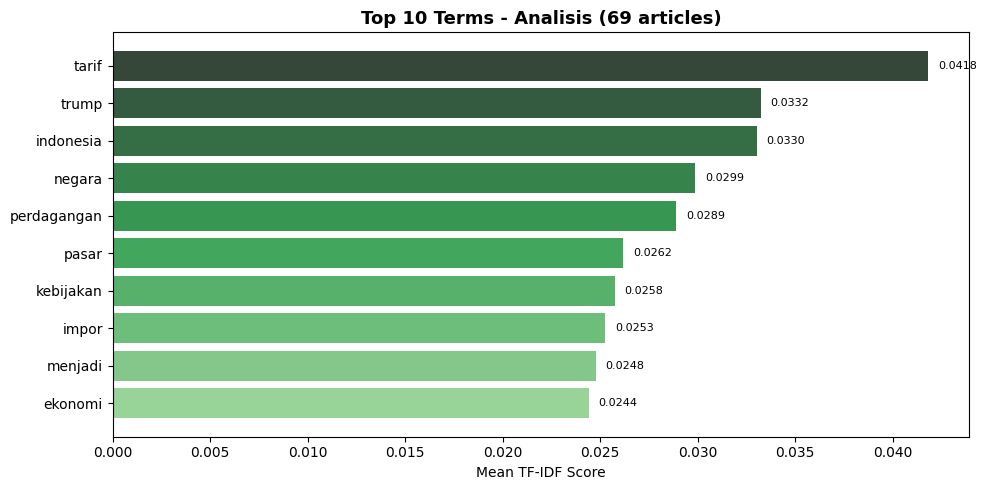

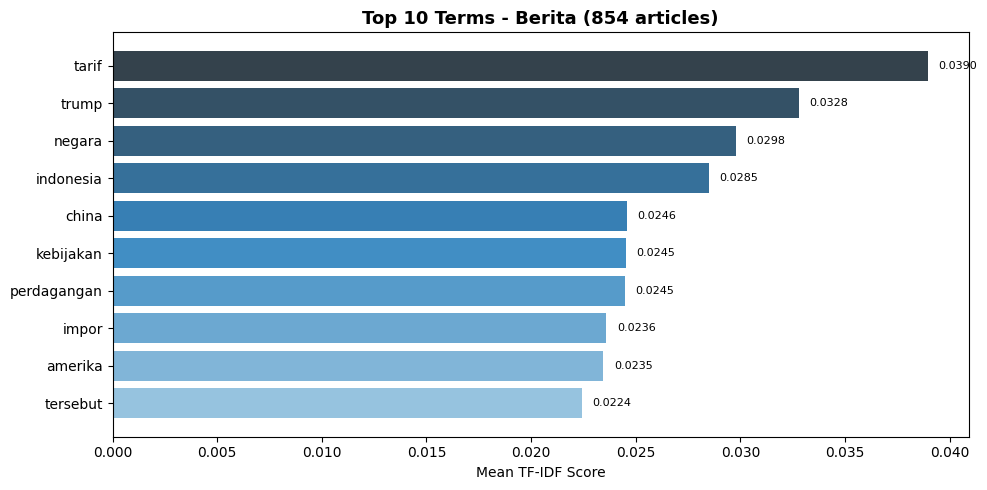

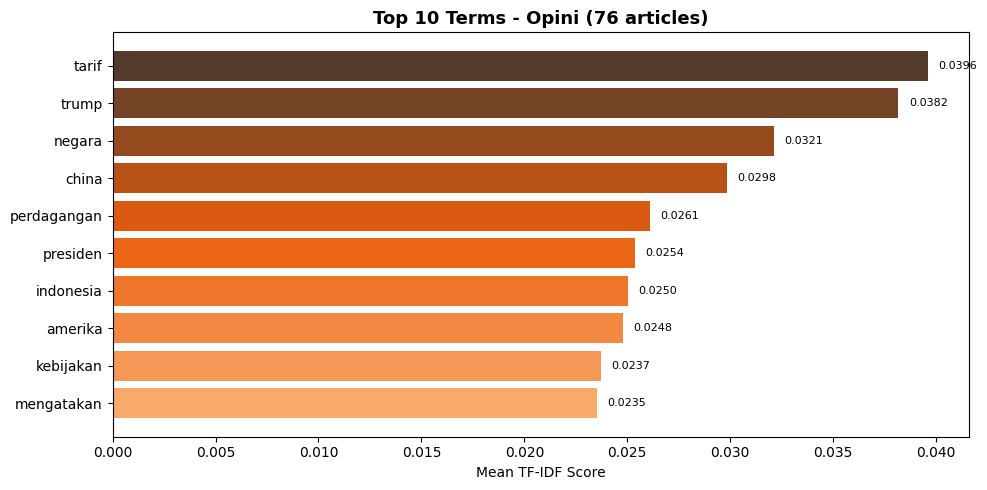

In [10]:
type_palettes = {
    'Berita': 'Blues_d', 'Opini': 'Oranges_d', 'Analisis': 'Greens_d',
    'Feature': 'Purples_d', 'Wawancara': 'Reds_d'
}

for dtype, df_t in sorted(tfidf_per_type.items()):
    data = df_t.head(10).iloc[::-1]
    fig, ax = plt.subplots(figsize=(10, 5))
    pal = type_palettes.get(dtype, 'viridis')
    colors = sns.color_palette(pal, len(data))
    ax.barh(data['Term'], data['TF-IDF Score'], color=colors)
    ax.set_xlabel('Mean TF-IDF Score')
    ax.set_title(f'Top 10 Terms - {dtype} ({data["Article Count"].iloc[0]} articles)',
                 fontsize=13, fontweight='bold')
    for i, val in enumerate(data['TF-IDF Score']):
        ax.text(val + 0.0005, i, f'{val:.4f}', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

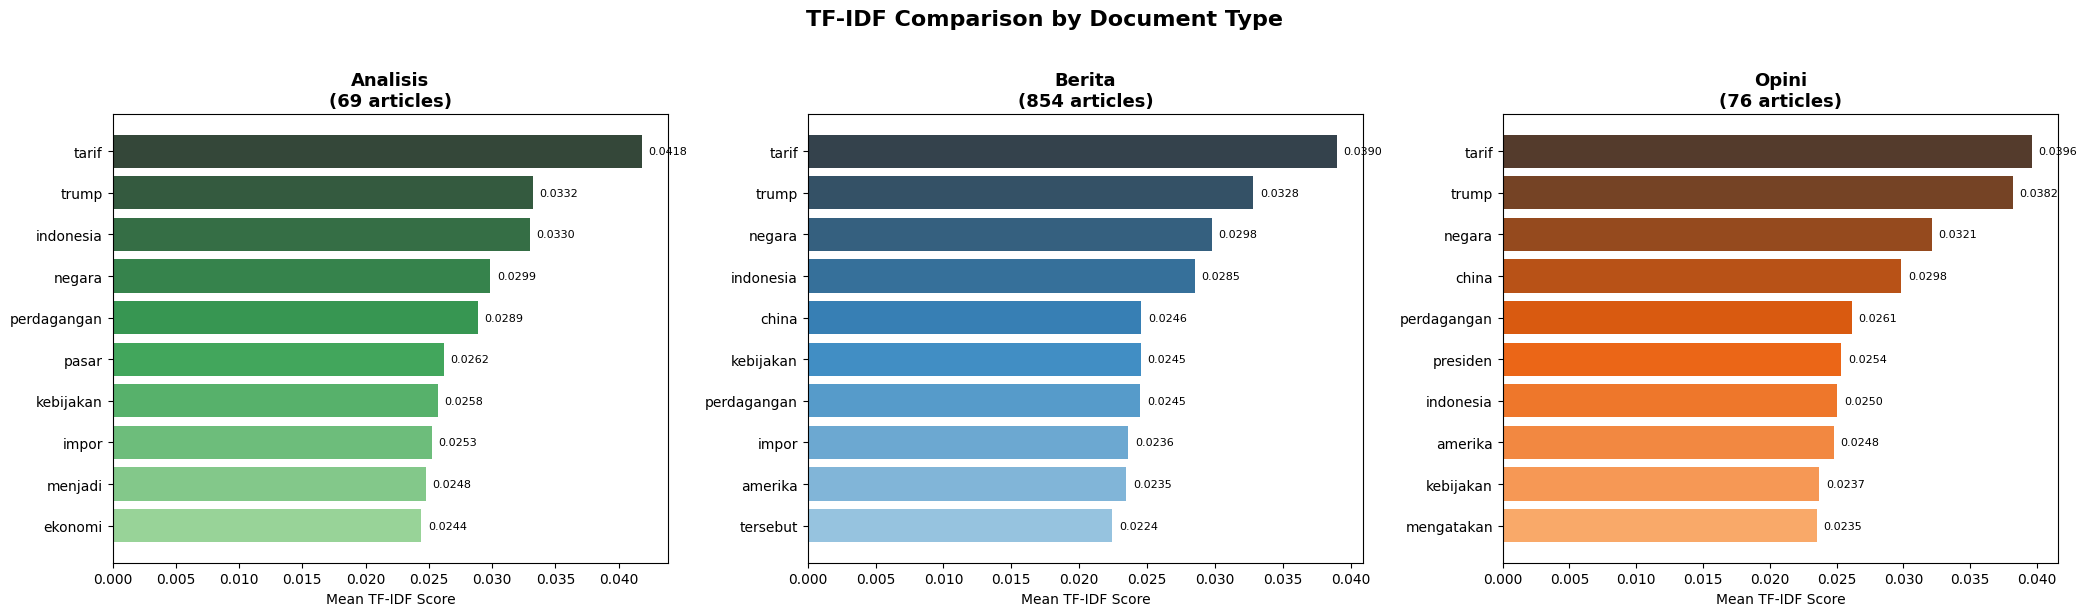

In [11]:
# Side-by-side comparison
n_types = len(tfidf_per_type)
if n_types >= 2:
    fig, axes = plt.subplots(1, n_types, figsize=(7 * n_types, 6))
    if n_types == 1: axes = [axes]
    
    for ax, (dtype, df_t) in zip(axes, sorted(tfidf_per_type.items())):
        top10 = df_t.head(10).iloc[::-1]
        pal = type_palettes.get(dtype, 'viridis')
        colors = sns.color_palette(pal, len(top10))
        ax.barh(top10['Term'], top10['TF-IDF Score'], color=colors)
        ax.set_title(f'{dtype}\n({top10["Article Count"].iloc[0]} articles)',
                     fontsize=13, fontweight='bold')
        ax.set_xlabel('Mean TF-IDF Score')
        for i, val in enumerate(top10['TF-IDF Score']):
            ax.text(val + 0.0005, i, f'{val:.4f}', va='center', fontsize=8)
    
    plt.suptitle('TF-IDF Comparison by Document Type', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## 6. Export to CSV

In [12]:
import os

OUTPUT_DIR = "../../outputs/tfidf_doctype"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Combined
all_types = pd.concat(tfidf_per_type.values(), ignore_index=True)
all_types.to_csv(f"{OUTPUT_DIR}/tfidf_by_doctype.csv", index=False)
print(f"Exported: tfidf_by_doctype.csv ({len(all_types)} rows)")

# Document type mapping
df_filtered[['url', 'judul', 'doc_type']].to_csv(
    f"{OUTPUT_DIR}/article_doctype_mapping.csv", index=False)
print(f"Exported: article_doctype_mapping.csv ({len(df_filtered)} rows)")

# Type stats
type_stats = df_filtered.groupby('doc_type').agg(
    article_count=('judul', 'count'),
    avg_length=('konten_length', 'mean')
).reset_index().sort_values('article_count', ascending=False)
type_stats.to_csv(f"{OUTPUT_DIR}/doctype_statistics.csv", index=False)
print(f"Exported: doctype_statistics.csv")

print(f"\nAll files: {os.path.abspath(OUTPUT_DIR)}")

Exported: tfidf_by_doctype.csv (60 rows)
Exported: article_doctype_mapping.csv (999 rows)
Exported: doctype_statistics.csv

All files: d:\Code\kelompok-7-pba\outputs\tfidf_doctype
